Проект №1.

Сканирование кубического мира: детекция персонажей в Minecraft с FCOS и YOLO.
Задача: предобучить детекторы FCOS и YOLO. Сравнить их.


In [117]:
import glob, os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
import pandas as pd
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco
from mmdet.apis import DetInferencer
import time

from mmdet.models.detectors import yolo

# Анализ входных данных

In [48]:
# Пути до данных:
DATA_PATH = 'D:/CV/mmdetection/mmdetection/datasets/minecraft/'

JSON

In [49]:
with open(f'{DATA_PATH}annotations/train/annotations.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [50]:
data.keys()

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])

Проверка соответствия изображений и аннотаций:

In [51]:
def check_img_annot(path, part):
    with open(f'{path}annotations/{part}/annotations.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

    annotations = []
    for i in range(len(data['images'])):
        annotations.append(data['images'][i]['file_name'].lower())
        
    imgs = [os.path.basename(x.lower()) for x in glob.glob(f'{path}/{part}/*.jpg')]
    
    imgs = set(imgs)
    annotations = set(annotations)

    print(f'Нет меток для изображений в {part}:', annotations - imgs)
    print(f'Нет изображений для меток в {part}:', imgs - annotations, end='\n')
    print()

In [52]:
check_img_annot(DATA_PATH, 'train')
check_img_annot(DATA_PATH, 'valid')
check_img_annot(DATA_PATH, 'test')

Нет меток для изображений в train: set()
Нет изображений для меток в train: set()

Нет меток для изображений в valid: set()
Нет изображений для меток в valid: set()

Нет меток для изображений в test: set()
Нет изображений для меток в test: set()



Отлично, все изображения и метки на месте.

Анализ распределения классов:

In [60]:
with open(f'{DATA_PATH}annotations/train/annotations.json', 'r', encoding="utf-8") as f:
    data = json.load(f)

In [61]:
classes = []
for i in range(len(data['annotations'])):
    classes.append(data['annotations'][i]['category_id'])

In [62]:
class_dict = []
for i in range(len(data['categories'])):
    class_dict.append(list(data['categories'][i].values())[:2])

In [63]:
classes = pd.Series(classes, name='class')
class_dict = pd.DataFrame(class_dict, columns=['class','class_name'])
class_dict = class_dict.set_index('class')
class_dict

,class_name
class,
0,minecraft-mobs
1,bee
2,chicken
3,cow
4,creeper
5,enderman
6,fox
7,frog
8,ghast


In [64]:
classes = pd.merge(classes, class_dict, on='class', how='left')

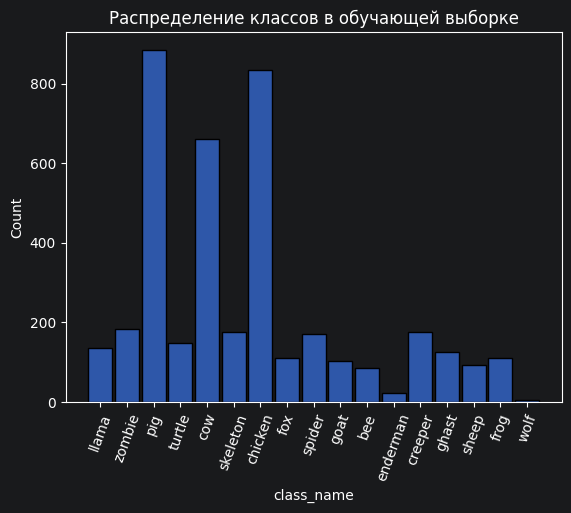

In [65]:
sns.histplot(data=classes,
             x='class_name',
             shrink=0.9)
plt.xticks(rotation=70)
plt.title("Распределение классов в обучающей выборке")
plt.show()

Вывод: Наблюдаем дисбаланс классов. Классы "свинка", "корова" и "курица" в 3-4 раза превышают по численности все остальные классы. Обычно я при нормальной представленности остальных классов избыточные обрезаю. Но пока оставим как есть.

Визуализация тестового примера из выборки для обучения.

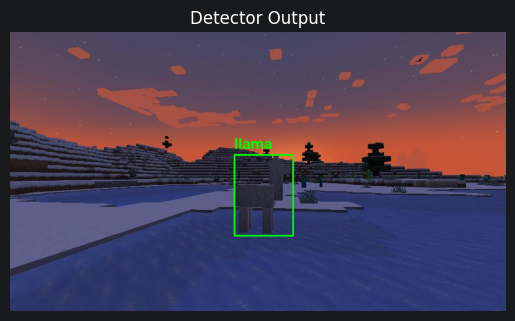

In [66]:
imge_path = f"{DATA_PATH}/train/{data['images'][0]['file_name']}"
image = cv2.imread(imge_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# image_rgb = image
x, y, w, h = data['annotations'][0]['bbox']
x_min, y_min = int(x), int(y)
x_max, y_max = int(x + w), int(y + h)

cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

class_id = data['annotations'][0]['category_id']

text = f"{class_dict.loc[class_id, 'class_name']}"

cv2.putText(image_rgb, text, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Отображаем результат с помощью Matplotlib
plt.imshow(image_rgb)
plt.axis('off') # Отключить оси
plt.title("Detector Output")
plt.show()

# FCOS

Протестируем скрипт на предобученной модели.

In [67]:
!python mmdetection/demo/image_demo.py mmdetection/datasets/minecraft/test/Minecraft-1-19-2-2022-11-30-4_44_58_png.rf.1d4d42b74b3973be56e49c40f2c10feb.jpg mmdetection/configs/fcos/fcos_minecraft.py --weights D:/CV/mmdetection/mmdetection/checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth --device cuda --out-dir artifacts/fcos/inference/test_pretrained

Loads checkpoint by local backend from path: D:/CV/mmdetection/mmdetection/checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([18, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([18]).
09/19 19:54:17 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.

Inference ----------------------------------------   
Inference ----------------------------------------   
Inference ---

D:\CV\mmdetection\project_1_venv\lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


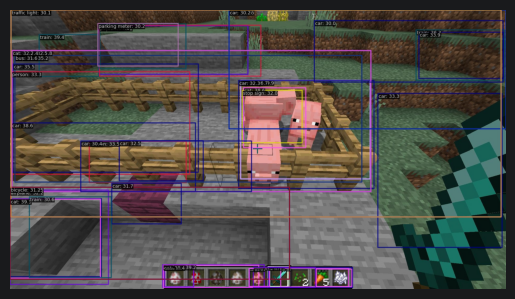

In [68]:
plt.imshow(Image.open(glob.glob(f'artifacts/fcos/inference/test_pretrained/vis/*.jpg')[0]))
plt.axis('off')
plt.show()

## Обучение

In [66]:
!python -u mmdetection/tools/train.py mmdetection/configs/fcos/fcos_minecraft.py --work-dir D:/CV/mmdetection/artifacts/fcos

CPU times: total: 0 ns
Wall time: 0 ns
09/18 16:45:32 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1217329869
    GPU 0: NVIDIA GeForce RTX 3050
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gen

D:\CV\mmdetection\project_1_venv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Метрики обучения

In [99]:
with open(f'D:/CV/mmdetection/artifacts/fcos/20260918_164531.json', 'r', encoding="utf-8") as f:
    data_fcos = pd.read_json('D:/CV/mmdetection/artifacts/fcos/20260918_164531.json', lines=True)

In [100]:
data_fcos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   base_lr           276 non-null    float64
 1   lr                276 non-null    float64
 2   data_time         288 non-null    float64
 3   grad_norm         276 non-null    float64
 4   loss              276 non-null    float64
 5   loss_cls          276 non-null    float64
 6   loss_bbox         276 non-null    float64
 7   loss_centerness   276 non-null    float64
 8   time              288 non-null    float64
 9   epoch             276 non-null    float64
 10  iter              276 non-null    float64
 11  memory            276 non-null    float64
 12  step              288 non-null    int64  
 13  coco/bbox_mAP     12 non-null     float64
 14  coco/bbox_mAP_50  12 non-null     float64
 15  coco/bbox_mAP_75  12 non-null     float64
 16  coco/bbox_mAP_s   12 non-null     float64
 1

In [95]:
data_fcos = data_fcos.loc[~data_fcos['coco/bbox_mAP'].isna()]

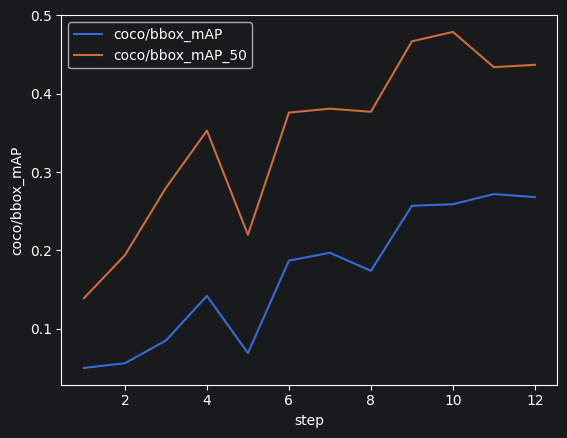

In [103]:
sns.lineplot(data_fcos, x='step', y='coco/bbox_mAP', label='coco/bbox_mAP')
sns.lineplot(data_fcos, x='step', y='coco/bbox_mAP_50', label='coco/bbox_mAP_50')
plt.show()

Метрики растут, но значения с такими настройками обучения невелики.

## Inference

In [69]:
inference_fcos ='D:/CV/mmdetection/artifacts/inference/fcos/'
config_path = 'D:/CV/mmdetection/mmdetection/configs/fcos/fcos_minecraft.py'
model = 'D:/CV/mmdetection/artifacts/fcos/epoch_12.pth'
test_img = 'D:/CV/mmdetection/mmdetection/datasets/minecraft/test/'

In [70]:
# Инференс тестовых изображений
inferencer = DetInferencer(
    model=config_path,
    weights=model,
    device='cuda:0',
    show_progress=False
)

inferencer(
    test_img,
    out_dir=inference_fcos,
    no_save_vis=False,       # не сохранять визуализации, если нужны только JSON
    no_save_pred=False      # сохранить предсказания в JSON
        )


Loads checkpoint by local backend from path: D:/CV/mmdetection/artifacts/fcos/epoch_12.pth


D:\CV\mmdetection\project_1_venv\lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
D:\CV\mmdetection\project_1_venv\lib\site-packages\mmengine\visualization\visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
D:\CV\mmdetection\project_1_venv\lib\site-packages\mmengine\visualization\visualizer.py:831: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(


{'predictions': [{'labels': [12,
    9,
    12,
    2,
    3,
    6,
    6,
    1,
    11,
    10,
    3,
    14,
    2,
    12,
    16,
    3,
    7,
    10,
    11,
    15,
    3,
    1,
    3,
    12,
    3,
    3,
    3,
    1,
    9,
    4,
    3,
    2,
    3,
    17,
    8,
    7,
    14,
    13,
    8,
    6,
    3,
    3,
    11,
    3,
    10,
    15,
    12,
    12,
    2,
    13,
    3],
   'scores': [0.26920920610427856,
    0.18414033949375153,
    0.15408794581890106,
    0.11592043191194534,
    0.10851193964481354,
    0.10664714127779007,
    0.1032467782497406,
    0.07809300720691681,
    0.060729436576366425,
    0.056460052728652954,
    0.04821079596877098,
    0.04301081597805023,
    0.03793910890817642,
    0.03723873198032379,
    0.03454819321632385,
    0.03242029994726181,
    0.03202291205525398,
    0.03183192387223244,
    0.0315154492855072,
    0.0296345092356205,
    0.02801206149160862,
    0.025895141065120697,
    0.025791000574827194,
    0.02528

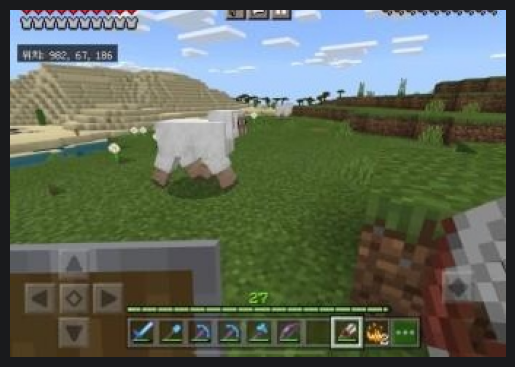

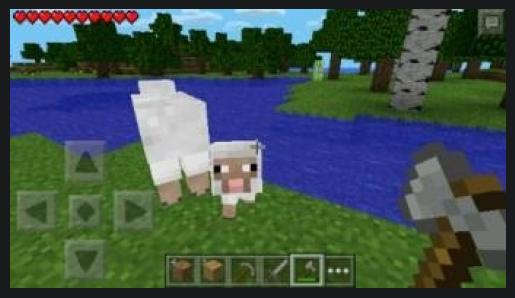

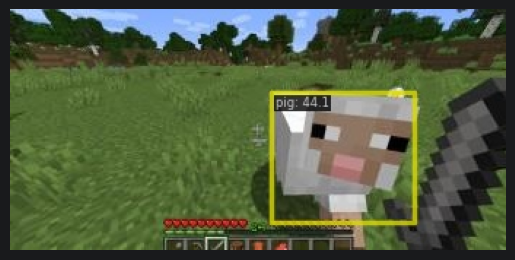

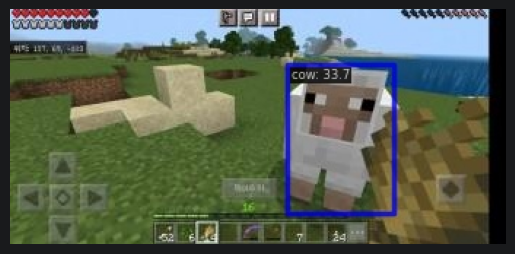

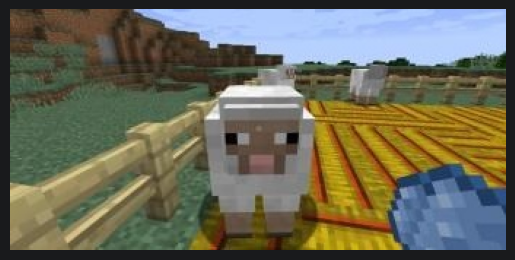

In [71]:
for i in range(5):
    plt.imshow(Image.open(glob.glob(f'{inference_fcos}vis/*.jpg')[i]))
    plt.axis('off')
    plt.show()

In [72]:
# Обработка видео по кадрам
video_path = 'D:/CV/mmdetection/mmdetection/datasets/minecraft/video.mp4'
output_video_path = 'D:/CV/mmdetection/artifacts/vidios/fcos_inference.mp4'


cap = cv2.VideoCapture(video_path)

frame_width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps          = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

frame_idx = 0
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # --- ИНФЕРЕНС ---
    result = inferencer(frame, no_save_vis=True)

    # --- ВИЗУАЛИЗАЦИЯ ---
    for pred in result['predictions']:
        for bbox, label_id, score in zip(pred['bboxes'], pred['labels'], pred['scores']):
            if score < 0.5: 
                continue
            x1, y1, x2, y2 = map(int, bbox)
            label = f"{inferencer.model.dataset_meta['classes'][label_id]} {score:.2f}"

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

Оценка точности на тестовой выборке.

In [83]:
# Не нашла более удобного и лаконичного метода для расчета ИИ предлагает простыню кода писать для этих вычислений. Но по идее же должно быть что-то удобнее.
!python mmdetection/tools/test.py mmdetection/configs/fcos/fcos_minecraft.py mmdetection/work_dirs/fcos_minecraft/epoch_12.pth

09/19 20:25:25 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1378813
    GPU 0: NVIDIA GeForce RTX 3050
    CUDA_HOME: None
    GCC: n/a
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;a

D:\CV\mmdetection\project_1_venv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [81]:
# Так себе вариант.
# !python mmdetection/tools/test.py mmdetection/configs/fcos/fcos_minecraft.py mmdetection/work_dirs/fcos_minecraft/epoch_12.pth  > mmdetection/results.txt 2>&1

In [87]:
# FPS
!python mmdetection/tools/analysis_tools/benchmark.py mmdetection/configs/fcos/fcos_minecraft.py --checkpoint mmdetection/work_dirs/fcos_minecraft/epoch_12.pth --repeat-num 1 --max-iter 2000 --log-interval 50

09/19 20:35:32 - mmengine - INFO - before build: 
09/19 20:35:32 - mmengine - INFO - (GB) mem_used: 14.84 | uss: 0.28 | total_proc: 1
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
09/19 20:35:32 - mmengine - INFO - after build: 
09/19 20:35:32 - mmengine - INFO - (GB) mem_used: 14.84 | uss: 0.29 | total_proc: 1
09/19 20:35:38 - mmengine - INFO - ==================================
09/19 20:35:38 - mmengine - INFO - Done batch [50 /2000], fps: 325.9 batch/s, times per batch: 3.1 ms/batch, batch size: 2, num_workers: 2
09/19 20:35:38 - mmengine - INFO - (GB) mem_used: 15.44 | uss: 0.87 | total_proc: 3
09/19 20:35:38 - mmengine - INFO - ============== Done ==================
09/19 20:35:38 - mmengine - INFO - Overall fps: 325.9 batch/s, times per batch: 3.1 ms/batch, batch size: 2, num_workers: 2
09/19 20:35:38 - mmengine - INFO - (GB) mem_used: 15.44 | uss: 0.87 | total_proc: 3


In [141]:
fcos_metrics = [0,0,325.9]

# YOLO

In [104]:
ANNOT_PATH = 'D:/CV/mmdetection/mmdetection/datasets/minecraft_yolo/'

In [105]:
# Преобразуем разметку из COCO в формат YOLO
for part in ['train', 'test', 'valid']:
    convert_coco(
            labels_dir=f'{ANNOT_PATH}/{part}',
            save_dir=f'{ANNOT_PATH}/{part}',
            cls91to80=False,
    )

COCO data converted successfully.
Results saved to D:\CV\mmdetection\mmdetection\datasets\minecraft_yolo\train-2
COCO data converted successfully.
Results saved to D:\CV\mmdetection\mmdetection\datasets\minecraft_yolo\test-2
COCO data converted successfully.
Results saved to D:\CV\mmdetection\mmdetection\datasets\minecraft_yolo\valid-2


In [106]:
# Тестовый запуск
!yolo predict model=yolov8n.pt source='mmdetection/datasets/minecraft/test/Minecraft-1-19-2-2022-11-30-4_44_58_png.rf.1d4d42b74b3973be56e49c40f2c10feb.jpg'

Ultralytics 8.4.155  Python-3.10.11 torch-2.0.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050, 8192MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 D:\CV\mmdetection\mmdetection\datasets\minecraft\test\Minecraft-1-19-2-2022-11-30-4_44_58_png.rf.1d4d42b74b3973be56e49c40f2c10feb.jpg: 384x640 (no detections), 5.4ms
Speed: 26.9ms preprocess, 5.4ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to D:\CV\mmdetection\runs\detect\predict-3
 Learn more at https://docs.ultralytics.com/modes/predict


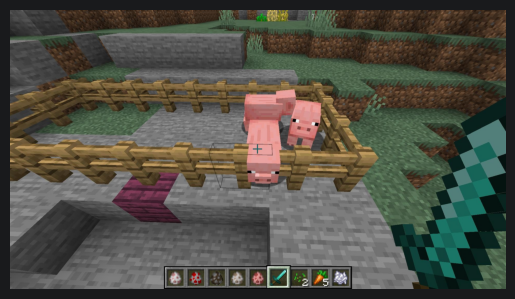

In [107]:
plt.imshow(Image.open(glob.glob(f'D:/CV/mmdetection/artifacts/inference/test_pretrained_yolo/*.jpg')[0]))
plt.axis('off')
plt.show()

## Обучение

In [55]:
!python ./yolo/train.py --data ./mmdetection/datasets/minecraft_yolo/data.yaml --epochs 12 --imgsz 512 --batch 2 --model yolov8n.pt --augment custom --name minecraft_lr

Ultralytics 8.4.155  Python-3.10.11 torch-2.0.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050, 8192MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./mmdetection/datasets/minecraft_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=minecraft_lr-2, n

Метрики обучения

In [112]:
data_yolo = pd.read_csv('D:/CV/mmdetection/artifacts/yolo/results.csv')
data_yolo.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,48.9383,1.49950,3.95042,1.11261,0.33625,0.16212,0.12234,0.08149,1.23659,4.10590,1.03756,0.000152,0.000152,0.000152
1,2,93.2803,1.41911,2.70867,1.11145,0.38350,0.21284,0.19050,0.13054,1.24721,4.00644,1.10748,0.000298,0.000298,0.000298
2,3,148.8850,1.36930,2.63833,1.10134,0.57997,0.19337,0.22372,0.14438,1.33181,3.76906,1.14969,0.000425,0.000425,0.000425
3,4,192.6670,1.32009,2.24889,1.07634,0.58585,0.21785,0.24584,0.15276,1.30433,3.59295,1.14433,0.000389,0.000389,0.000389
4,5,235.5760,1.25923,2.01135,1.05692,0.44139,0.23643,0.28351,0.18044,1.27740,3.34767,1.16319,0.000342,0.000342,0.000342


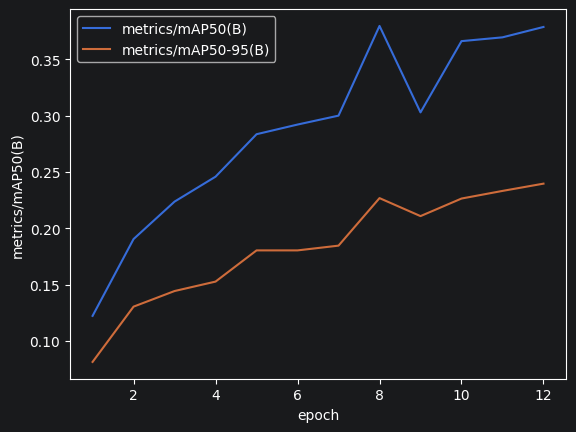

In [113]:
sns.lineplot(data_yolo, x='epoch', y='metrics/mAP50(B)', label='metrics/mAP50(B)')
sns.lineplot(data_yolo, x='epoch', y='metrics/mAP50-95(B)', label='metrics/mAP50-95(B)')
plt.show()

Здесь тоже все метрики растут.

## Inference

In [114]:
yolo_model = YOLO('D:/CV/mmdetection/artifacts/yolo/weights/best.pt')
yolo_output = 'D:/CV/mmdetection/artifacts/inference/yolo'
for img in glob.glob(f'{test_img}*jpg'):
    inference =  yolo_model(img, imgsz=512, conf=0.5, verbose=False)
    inference[0].save(filename=f'{yolo_output}/{os.path.basename(img)}')

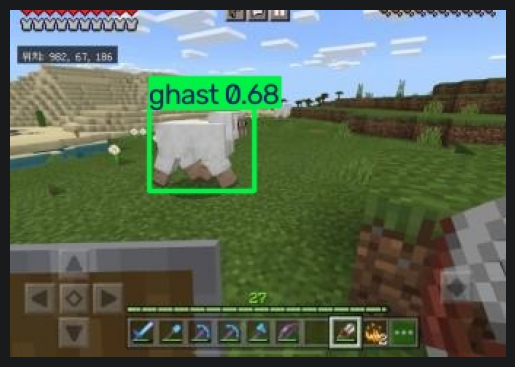

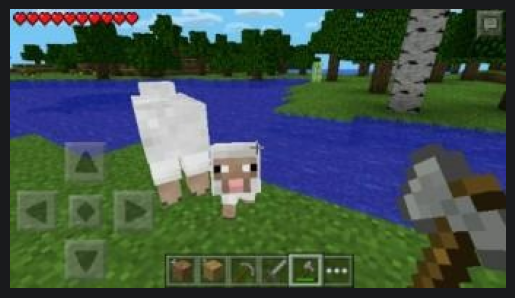

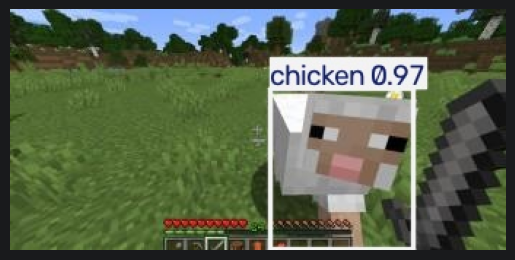

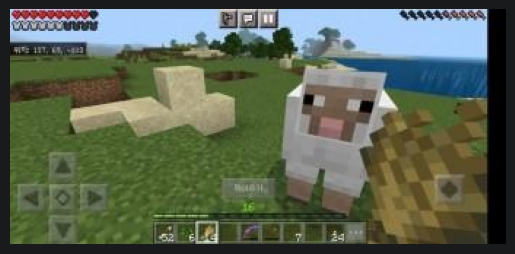

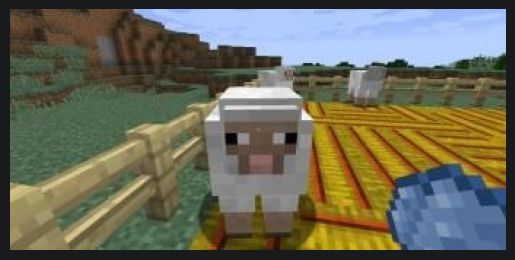

In [115]:
for i in range(5):
    plt.imshow(Image.open(glob.glob(f'{yolo_output}/*.jpg')[i]))
    plt.axis('off')
    plt.show()

Видео

In [118]:
video_path = 'D:/CV/mmdetection/mmdetection/datasets/minecraft/video.mp4'
output_video_path = 'D:/CV/mmdetection/artifacts/vidios/yolo_inference.mp4'


cap = cv2.VideoCapture(video_path)

frame_width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps          = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

frame_idx = 0
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # --- ИНФЕРЕНС ---
    results = yolo_model(frame, imgsz=512, conf=0.5, verbose=False)

    # --- ВИЗУАЛИЗАЦИЯ ---
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf       = float(box.conf[0])
            class_id   = int(box.cls[0])
            label      = f"{yolo_model.names[class_id]} {conf:.2f}"

            # цвет обязателен! (B, G, R)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # (x, y) — координаты, а не кортеж в качестве текста
            cv2.putText(frame, label, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # --- Счётчик кадров (вне цикла по боксам!) ---
    cv2.putText(frame, f"Frame: {frame_idx}", (50, 50),
                cv2.FONT_HERSHEY_TRIPLEX, 1.5, (0, 255, 255), 3)

    # --- Запись кадра (вне цикла по боксам!) ---
    out.write(frame)
    frame_idx += 1

# --- Освобождение ресурсов (вне цикла!) ---
cap.release()
out.release()
cv2.destroyAllWindows()

In [154]:
yolo_m = yolo_model.val(data=f'{ANNOT_PATH}/data.yaml', imgsz=640)

Ultralytics 8.4.155  Python-3.10.11 torch-2.0.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050, 8192MiB)
Model summary (fused): 72 layers, 3,009,158 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2566.2525.8 MB/s, size: 255.6 KB)
val: Scanning D:\CV\mmdetection\mmdetection\datasets\minecraft_yolo\valid\labels.cache... 422 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 422/422  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 9.1it/s 3.0s<0.1s
                   all        422        697      0.638      0.281      0.319      0.226
                   bee         10         14      0.586      0.357      0.292      0.179
               chicken         88        127      0.878      0.425       0.43      0.294
                   cow        123        123       0.95      0.976       0.98      0.809
               creeper        103        103      0.941      0.154      0.703      0.415
     

In [135]:
# Вот тут код из DeepSeak в чистом виде, тут я полный ноль. По ходу разобраась, но не воспроизведу.
cap = cv2.VideoCapture(video_path)
frame_count = 0
start_time = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Инференс (без вывода)
    _ = yolo_model(frame, verbose=False)
    frame_count += 1

elapsed = time.time() - start_time
fps = frame_count / elapsed

print(f"FPS: {fps:.2f}")
cap.release()

FPS: 74.49


In [168]:
yolo_metrics = [[yolo_m.box.map, yolo_m.box.map50, fps]]
yolo_metrics

[[0.22589727999634068, 0.318690983141596, 74.48619597253207]]

Собираем все метрики и экспортируем.

In [169]:
yolo_metrics.append(fcos_metrics)

In [175]:
data_all = pd.DataFrame(yolo_metrics, columns=['mAP', 'mAP_50', 'FPS'])

In [178]:
data_all.index = ['YOLO', 'FCOS']

In [180]:
data_all.to_csv('D:/CV/mmdetection/artifacts/metrics/metrics_comparison.csv')

In [190]:
data_all

,mAP,mAP_50,FPS
YOLO,0.225897,0.318691,74.486196
FCOS,0.000000,0.000000,325.900000
